# Assignment 2: Scalability of Support Vector Machines
## Miles Nordwall, Nathan Nail

In [38]:
import numpy as np
from datetime import datetime

In [40]:
NUM_ITER = 100
ETA = 0.01
EPOCHS = 50

#global variable to keep track of runtimes of each model
SVC_IRIS_t = 0.0

### Task #1 Implement LinearSVC

In [60]:
class LinearSVC(object):
    """
    Linear Support Vector Classifier
    Params: 
    eta (float) : Learning rate (between 0.0 and 1.0)
    n_iter (int) : Number of passes over the training dataset.
    random_state (int) : Random number generator seed for random weight initialization.

    Attrs:
    w_ (1d-array) : Weights after fitting with bias absorbed at X[0].
    losses_ (list) : Hinge Loss with L2-regularization loss function values in each epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.rand_gen = []
        self.w_initialized = False

    def fit(self, X, y, C=0.1):
        """
        Learns parameters from the training data
        Uses SGD
        Params:
        X {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
        y (array-like) ,shape = [n_examples]
        Target values.
        C {float} = regularization hyperparameter 

        Returns:
        self : Instance of LinearSVC
        """
        self.losses_ = []
        X = self._initialize_weights(X,X.shape[1])
        c_n = C /X.shape[0]
        
        for _ in range(self.n_iter):
            
            X, y = self._shuffle(X, y)
            epoch_losses = []
            
            for xi, yi in zip(X, y):
                
                y_hat = self.net_input(xi)
                fn_margin = 1 - (yi*y_hat)
                Li = np.maximum(0,fn_margin)

                #gd = self.w_ + c_n * (-yi*xi) #dL/dw
                b_update = 0
                if fn_margin > 0: #case 1
                    gd = self.w_ + c_n * (-yi*xi) #dL/dw
                    b_update = -yi
                else: #case 2
                    gd = self.w_
                epoch_losses.append(Li)
                self.w_ += self.eta* (-gd)
                self.b_ += self.eta* b_update
            avg_loss = np.mean(epoch_losses)
            self.losses_.append(avg_loss)
        return self
        

    
    def _initialize_weights(self, X, m):
        """Initialize weights to small random numbers
        """
        self.b_ = np.float_(0.)
        self.rand_gen = np.random.RandomState(self.random_state)
        self.w_ = self.rand_gen.normal(loc=0.0, scale=0.01,
                                  size=m)
        self.w_initialized = True
        return X
        

    def _update_weights(self, xi, y):
        """Calculate hinge loss then apply GD to L wrt w_"""
        y_hat = self.net_input(xi)
        Li = np.max(0, 1 - (y*y_hat))
        loss = c_n * (Li + (0.5 * (self.w_.shape[0])^2))
        self.w_ += self.w_ + self.eta - loss
        self.b_ += gd
        return loss
        
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rand_gen.permutation(len(y))
        return X[r], y[r]

    def net_input(self, X): #TODO1 the net_input for svc is w^Tx-b right? unabsorb b?
        """Calculate net input"""
        return np.dot(X, self.w_) - self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.sign(self.net_input(X))
    
        

### Task #2 make_classification function
$$\bar{a}^T \bar{x} = b$$
$$\{ \bar{x} \in \mathbb{R}^d | \bar{a}^T \bar{x} = b\}$$
$$\text{where } b=0$$

In [100]:
from sklearn.model_selection import train_test_split
def make_classification(d,n, u=100,seed=1):
    """
    Generates a set of linearly seperable data
    based on a random seperation hyperplane
    d (int) : dimension of set of points
    """
    rand_gen = np.random.RandomState(seed)
    #generate random vector a s.t ||a||=d
    a = rand_gen.random(size=d) #TODO values are between [0-1] btw, is that okay?
    
    #randomly select n samples in range of [-u,u] in each dimension using a gaussian
    
    X = rand_gen.normal(scale=u,size=(n,d))    
    
    #give each xi a label yi 
    y = []
    for j in range(n):
        if a.T.dot(X[j]) < 0: #is this correct?
            yi = -1
        else:
            yi = 1
        y.append(yi)
    Y = np.array(y)

    split_idx = int(np.ceil(n * 0.7))
    X_train, X_test = np.split(X, [split_idx])
    Y_train, Y_test = np.split(Y, [split_idx])

    
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

    
    return X_train, X_test, Y_train, Y_test

In [102]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None,
                          resolution=0.02):
    #taken from textbook
    # setup marker generator and color map
    markers = ('o', 'x', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Test set')

/var/folders/q8/dkdmw0695vz4xd77f20xf2h00000gp/T/ipykernel_2449/127553513.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


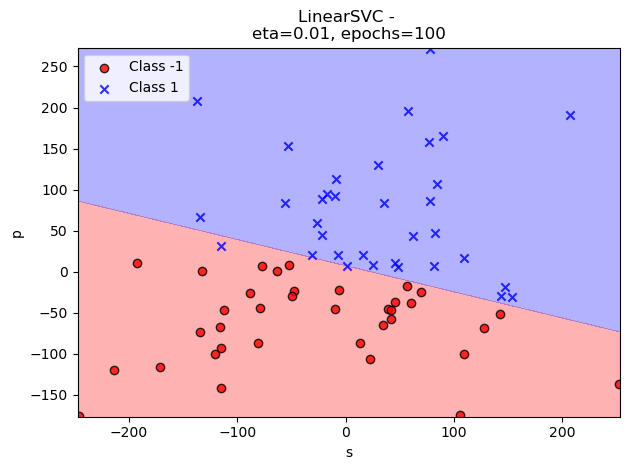

In [104]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=100, eta=0.001)
X_train, X_test, Y_train, Y_test = make_classification(d=2,n=100,u=100,seed=96)


svc_start = datetime.now()
svc.fit(X_train, Y_train)
svc_end = datetime.now()
SVC_t = (svc_end - svc_start).total_seconds() *1000

plot_decision_regions(X_train, Y_train, classifier=svc)
plt.title(f'LinearSVC - \n'
          f'eta={ETA}, epochs={NUM_ITER}')
plt.xlabel('s')
plt.ylabel('p')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

   Epochs  Dim  Samples       Time  Loss Convergence
0      50   10      500   0.130657          1.260791
1      50   10     5000   1.179326          0.332522
2      50   10    50000  11.861579          0.035093
3      50   50      500   0.119400          1.879156
4      50   50     5000   1.175993          0.485220
5      50   50    50000  12.069056          0.046418
6      50  100      500   0.118881          2.445396
7      50  100     5000   1.205145          0.682255
8      50  100    50000  12.283338          0.061489


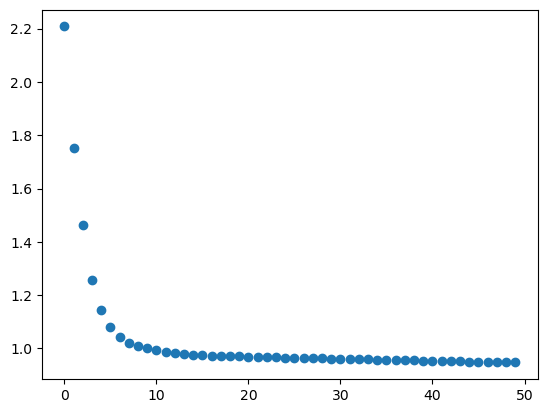

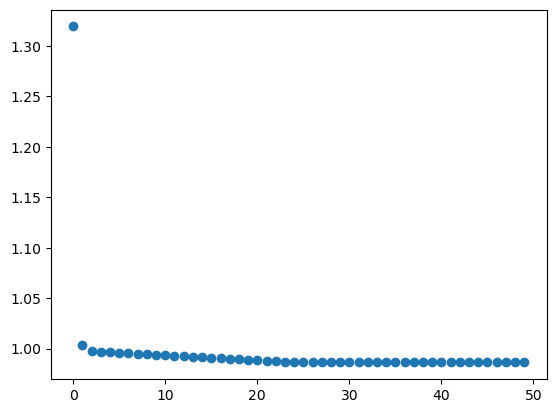

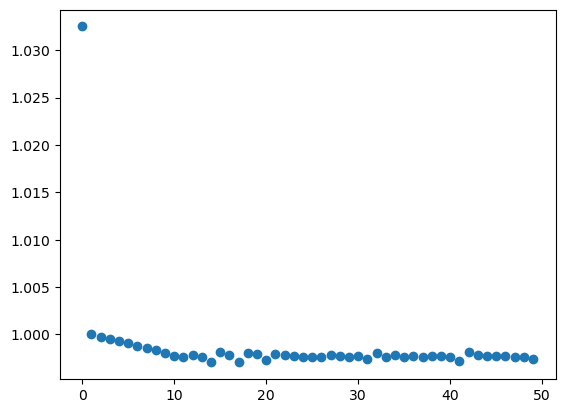

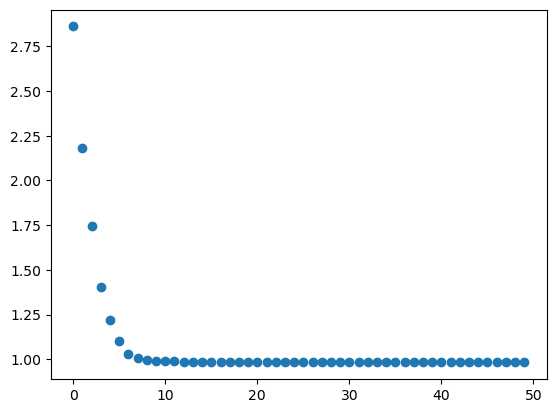

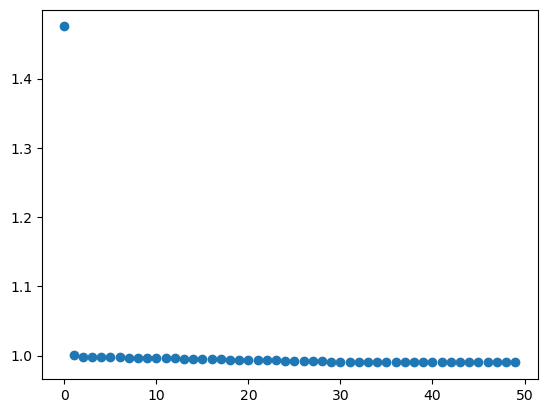

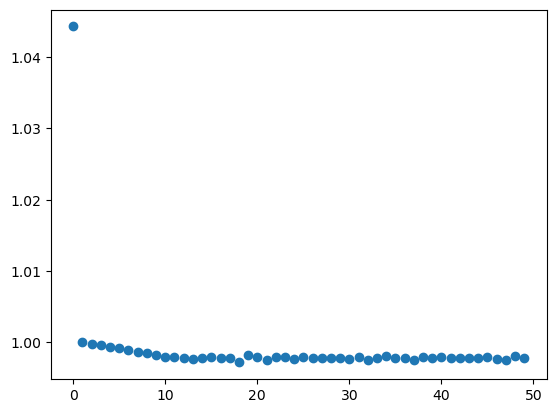

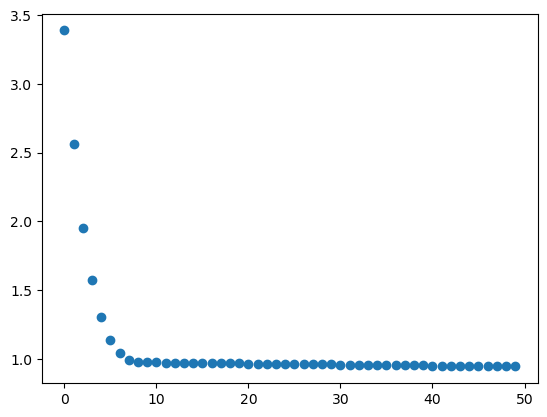

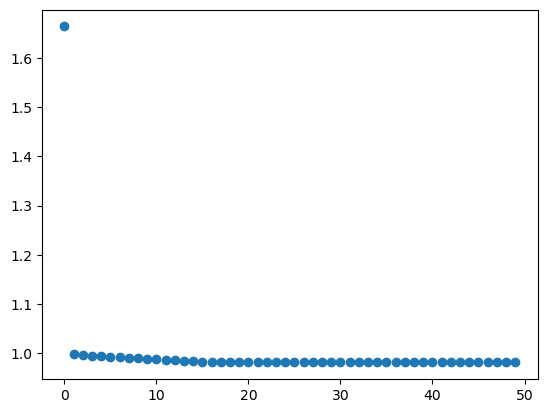

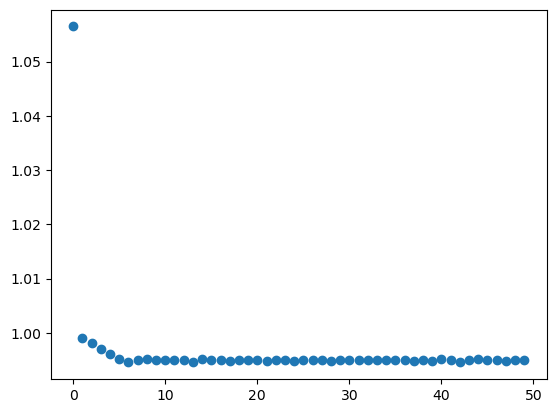

In [105]:
#from LinearSVC import LinearSVC as mySVC
#from sklearn.svm import LinearSVC as skSVC
import time
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt 

"""
Investigate the scalability of the LinearSVC class you have implemented. Using the dataset
generator developed in the previous task, you may produce random datasets regarding to the 9 combinations
of the following scales: d = 10, 50, 100 and n = 500, 5000, 50000. You may assign a large constant such
as 100 to u. (Please feel free to slightly adjust the scales according to your computer’s hardware.) Evaluate
the time cost and loss convergence of your linear SVC on the 9 datasets. The comparison should be given
by tables along with explanations.
"""

import itertools

n_dims = [10, 50, 100]
n_samples = [500, 5000, 50000]

sets = []
errors = []

headers = ["Epochs","Dim","Samples","Time","Loss Convergence"]
d_s = []
svc1 = LinearSVC(n_iter=50, eta=0.001)

def plot_losses(loss_values : list):
    x_vals = np.linspace(0, 49, 50)
    plot = plt.plot()
    plt.scatter(x = x_vals, y = loss_values)
    plt.show()

for dims, samples in itertools.product(n_dims, n_samples):
    X_train, X_test, Y_train, Y_test = make_classification(d=dims,n=samples,u=100,seed=96)
    
    fit_start = time.clock_gettime(5)
    svc1.fit(X_train, Y_train, 0.001)
    fit_end = time.clock_gettime(5)
    
    
    end_weight = svc1.w_
    errors.append(svc1.losses_)

    d_s.append([EPOCHS, dims, samples, fit_end - fit_start, svc1.losses_[0] - svc1.losses_[-1]])  #drop in loss from first to last sample
    
np.set_printoptions(suppress=True, precision=4)
table = pd.DataFrame(d_s, columns=headers)
print(table)

for l in errors:
    plot_losses(l)

Dual Table:
   Converged At  Dim  Samples      Time  Accuracy
0          2405   10      500  0.003994  1.000000
1          2790   10     5000  0.020486  0.999714
2          4092   10    50000  0.228538  0.999686
3          7352   50      500  0.077536  1.000000
4          9167   50     5000  0.229257  1.000000
5         14637   50    50000  1.653928  0.999171
6          2321  100      500  0.102696  1.000000
7         22450  100     5000  0.935230  1.000000
8         21367  100    50000  4.140213  0.999600
Primal Table:
   Converged At  Dim  Samples      Time  Accuracy
0            10   10      500  0.000592  1.000000
1            11   10     5000  0.002344  1.000000
2            13   10    50000  0.022120  0.999686
3            22   50      500  0.002246  1.000000
4            12   50     5000  0.009149  1.000000
5            12   50    50000  0.094441  0.999171
6           124  100      500  0.033659  1.000000
7            13  100     5000  0.020833  1.000000
8            14  100    

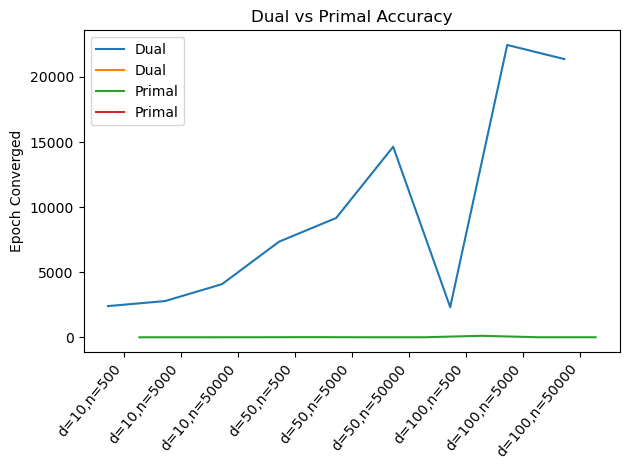

In [162]:
#from LinearSVC import LinearSVC as mySVC
from sklearn.svm import LinearSVC as skSVC
import time
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt 

"""
Investigate the scalability of the LinearSVC class you have implemented. Using the dataset
generator developed in the previous task, you may produce random datasets regarding to the 9 combinations
of the following scales: d = 10, 50, 100 and n = 500, 5000, 50000. You may assign a large constant such
as 100 to u. (Please feel free to slightly adjust the scales according to your computer’s hardware.) Evaluate
the time cost and loss convergence of your linear SVC on the 9 datasets. The comparison should be given
by tables along with explanations.
"""

import itertools

n_dims = [10, 50, 100]
n_samples = [500, 5000, 50000]


headers = ["Converged At","Dim","Samples","Time","Accuracy"]
d_s_d = []
d_s_p = []
conv_d = []
conv_p = []


for dims, samples in itertools.product(n_dims, n_samples):
    X_train, X_test, Y_train, Y_test = make_classification(d=dims,n=samples,u=100,seed=96)
    
    fit_start = time.clock_gettime(5)
    dual = skSVC(loss = "squared_hinge", dual = True, max_iter=50000, C=0.001)
    dual.fit(X = X_train, y = Y_train)
    fit_end = time.clock_gettime(5)

    fit_start_p = time.clock_gettime(5)
    primal = skSVC(loss = "squared_hinge", dual = False, max_iter=50000, C=0.001)
    primal.fit(X = X_train, y = Y_train)
    fit_end_p = time.clock_gettime(5)
    
    result_d = dual.predict(X_train)
    accuracy_d = dual.score(X_train, Y_train)
    
    result_p = primal.predict(X_train)
    accuracy_p = primal.score(X_train, Y_train)
    
    
    conv_d.append(dual.n_iter_)
    conv_p.append(primal.n_iter_)

    #print([dual.n_iter_, dims, samples, fit_end - fit_start, accuracy_d])
    #print([primal.n_iter_, dims, samples, fit_end_p - fit_start_p, accuracy_p])
    
    d_s_d.append([dual.n_iter_, dims, samples, fit_end - fit_start, accuracy_d])  #drop in loss from first to last sample
    d_s_p.append([primal.n_iter_, dims, samples, fit_end_p - fit_start_p, accuracy_p])  #drop in loss from first to last sample
    
np.set_printoptions(suppress=True, precision=4)
table_d = pd.DataFrame(d_s_d, columns=headers)
table_p = pd.DataFrame(d_s_p, columns=headers)
print("Dual Table:")
print(table_d)
print("Primal Table:")
print(table_p)

x = range(len(conv_d))
labels = [f"d={d},n={n}" for d,n in itertools.product(n_dims, n_samples)]
width = 0.55

fig,axes = plt.subplots()
axes.plot([i - width/2 for i in x], conv_d, width, label='Dual')
axes.plot([i + width/2 for i in x], conv_p, width, label='Primal')
axes.set_xticks(list(x))
axes.set_xticklabels(labels, rotation=50, ha='right')
axes.set_ylabel('Epoch Converged')
axes.set_title('Dual vs Primal Accuracy')
axes.legend()
plt.tight_layout()
plt.show()

